In [1]:
import os
if os.path.basename(os.getcwd()) == 'Demonstrations':
    os.chdir('..')

<div style="background-color: #bee7ff; color: white; padding: 30px; border-radius: 0px;">
<h1 style="margin: 0;  color: #1e1a66">Reduced Order Modeling on Stokes Equations</h1>
<h3 style="margin: 0;  color: #1e1a66">No clear Onine/Offline phases</h3>
</div>

Imports:

In [2]:
import numpy as np
import scipy.sparse.linalg as spla
import scipy.sparse as sp

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

from Utilities.Mesh_processing import refine
from Utilities.Plot_functions import (
    Plot_Initial_Refined_meshes, plot_viscosity, 
    plot_combined_solution, 
    K_matrix_structure
    )

from Solvers.Exchanger_Device import (
    compute_U_P_solution_exchanger_device,
    parabolic_inlet_profile
)

from Utilities.Stokes_felib import (
    calculate_velocity_A, 
    calculate_pressure_B)

Datasets:

In [3]:
visc_path = os.path.join('Reduced_Order_Modeling/No_Online_Offline_phase', 'Data', 'viscosity_snapshots.npz')
sol_path  = os.path.join('Reduced_Order_Modeling/No_Online_Offline_phase', 'Data', 'stokes_solution_snapshots.npz')

for path in [visc_path, sol_path]:
    print(f"\nFile: {path}")
    with np.load(path) as data:
        for key in data.files:
            print(f"  Key: {key:<20} Shape: {data[key].shape}")

with np.load(visc_path) as data_v:
    v_t_snapshots = data_v['v_t_snapshots']
    parameters    = data_v['parameters']
    knots         = data_v['knots']

with np.load(sol_path) as data_s:
    ux_snapshots = data_s['ux_snapshots']
    uy_snapshots = data_s['uy_snapshots']
    p_snapshots  = data_s['p_snapshots']


File: Reduced_Order_Modeling/No_Online_Offline_phase/Data/viscosity_snapshots.npz
  Key: v_t_snapshots        Shape: (100, 180480)
  Key: parameters           Shape: (100, 5)
  Key: knots                Shape: (5, 2)
  Key: p_fine               Shape: (91273, 2)
  Key: t_fine               Shape: (180480, 7)
  Key: e_fine               Shape: (271752, 3)

File: Reduced_Order_Modeling/No_Online_Offline_phase/Data/stokes_solution_snapshots.npz
  Key: ux_snapshots         Shape: (100, 91273)
  Key: uy_snapshots         Shape: (100, 91273)
  Key: p_snapshots          Shape: (100, 23077)
  Key: parameters           Shape: (100, 5)
  Key: p_fine               Shape: (91273, 2)
  Key: t_fine               Shape: (180480, 7)
  Key: e_fine               Shape: (271752, 3)
  Key: p_coarse             Shape: (23077, 2)
  Key: t_coarse             Shape: (45120, 7)


---

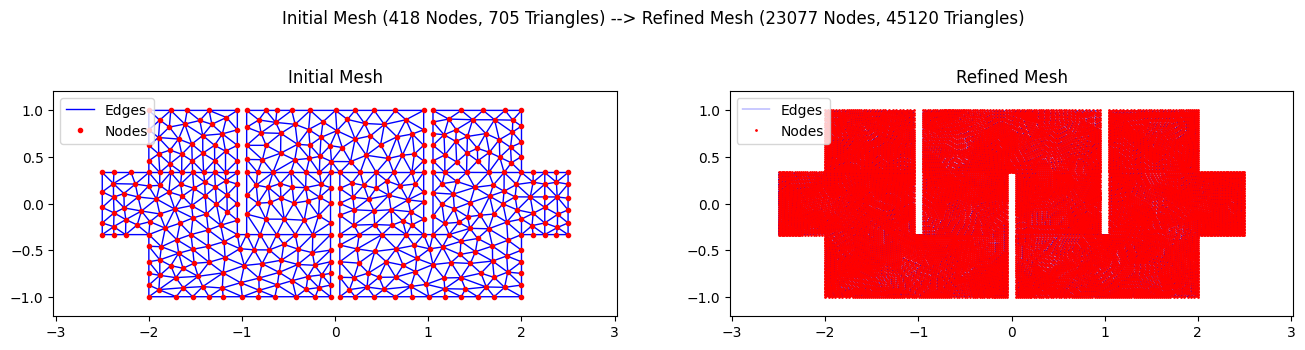

In [4]:
p_coarse, e_coarse, t_coarse = Plot_Initial_Refined_meshes(data_path='Meshes/exchanger_device_altered_mesh_data.npz', num_of_refinements=3, 
                                                           plot=True,
                                                           figsize=(16,4))
p_fine, e_fine, t_fine = refine(p_coarse, e_coarse, t_coarse)

### Viscosity Snapshots

--- GLOBAL STATISTICS ---
Total Snapshots:      100
Elements per Mesh:    180480
Absolute Min ( >0? ): 10.393727
Absolute Max:         199.933392
Global Mean:          104.978799

--- SPATIAL VARIABILITY ---
Highest variability at element 109112 (Std: 54.865639)
Lowest variability is 27.125424

--- INTRINSIC DIMENSIONALITY ---
Modes needed to capture 99.9% of viscosity variance: 5


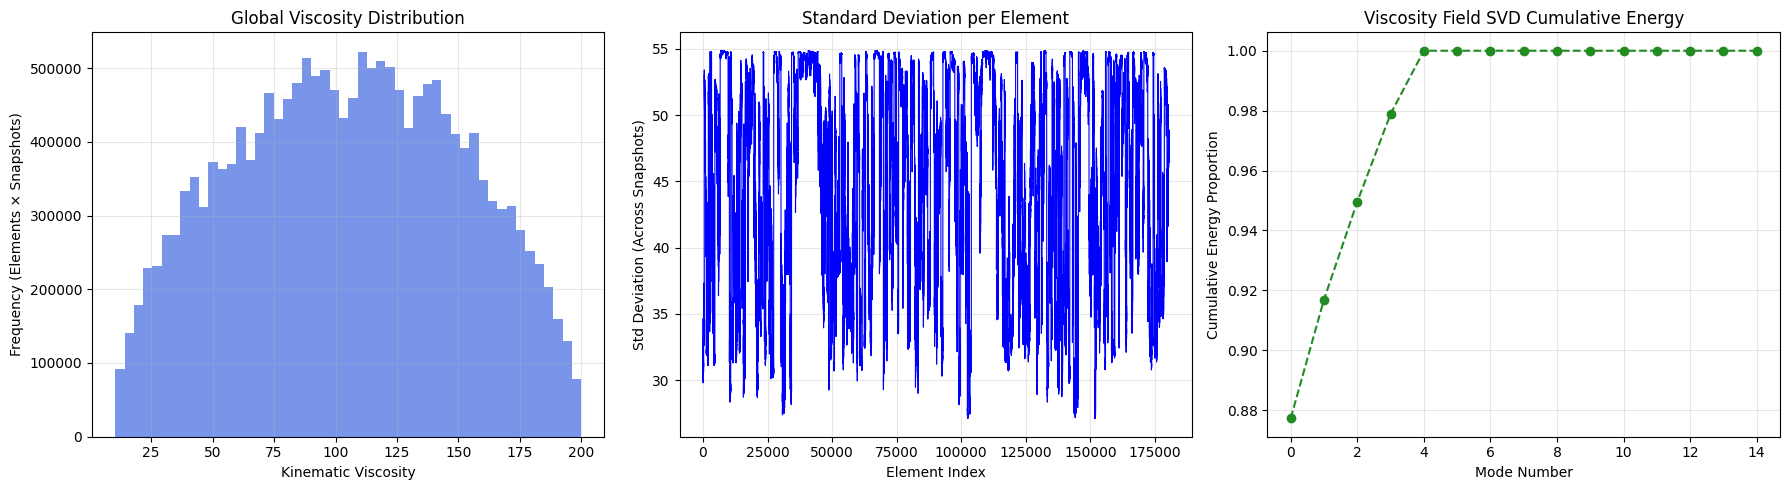

In [5]:
n_snapshots, n_elements = v_t_snapshots.shape

print("--- GLOBAL STATISTICS ---")
print(f"Total Snapshots:      {n_snapshots}")
print(f"Elements per Mesh:    {n_elements}")
print(f"Absolute Min ( >0? ): {np.min(v_t_snapshots):.6f}")
print(f"Absolute Max:         {np.max(v_t_snapshots):.6f}")
print(f"Global Mean:          {np.mean(v_t_snapshots):.6f}")

element_std = np.std(v_t_snapshots, axis=0)
max_var_elem = np.argmax(element_std)

print("\n--- SPATIAL VARIABILITY ---")
print(f"Highest variability at element {max_var_elem} (Std: {np.max(element_std):.6f})")
print(f"Lowest variability is {np.min(element_std):.6f}")

# Dimensionality / Complexity
_, S, _ = np.linalg.svd(v_t_snapshots, full_matrices=False)
energy = np.cumsum(S**2) / np.sum(S**2)
modes_99 = np.searchsorted(energy, 0.999) + 1

print("\n--- INTRINSIC DIMENSIONALITY ---")
print(f"Modes needed to capture 99.9% of viscosity variance: {modes_99}")

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(v_t_snapshots.flatten(), bins=50, color='royalblue', alpha=0.7)
axes[0].set_title("Global Viscosity Distribution")
axes[0].set_xlabel("Kinematic Viscosity")
axes[0].set_ylabel("Frequency (Elements × Snapshots)")
axes[0].grid(alpha=0.3)

axes[1].plot(element_std, color='blue', linewidth=0.8)
axes[1].set_title("Standard Deviation per Element")
axes[1].set_xlabel("Element Index")
axes[1].set_ylabel("Std Deviation (Across Snapshots)")
axes[1].grid(alpha=0.3)

axes[2].plot(energy[:15], marker='o', color='forestgreen', linestyle='--')
axes[2].set_title("Viscosity Field SVD Cumulative Energy")
axes[2].set_xlabel("Mode Number")
axes[2].set_ylabel("Cumulative Energy Proportion")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

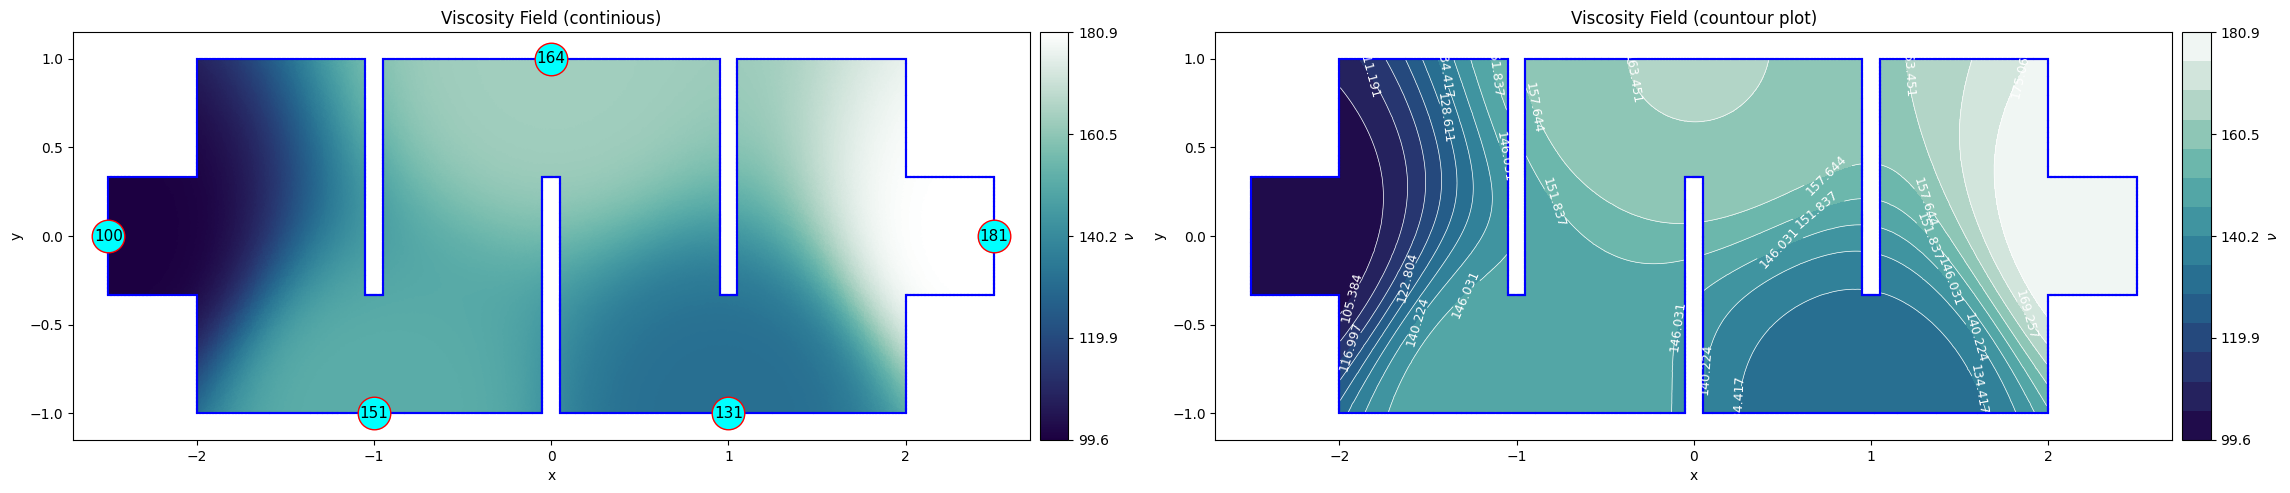

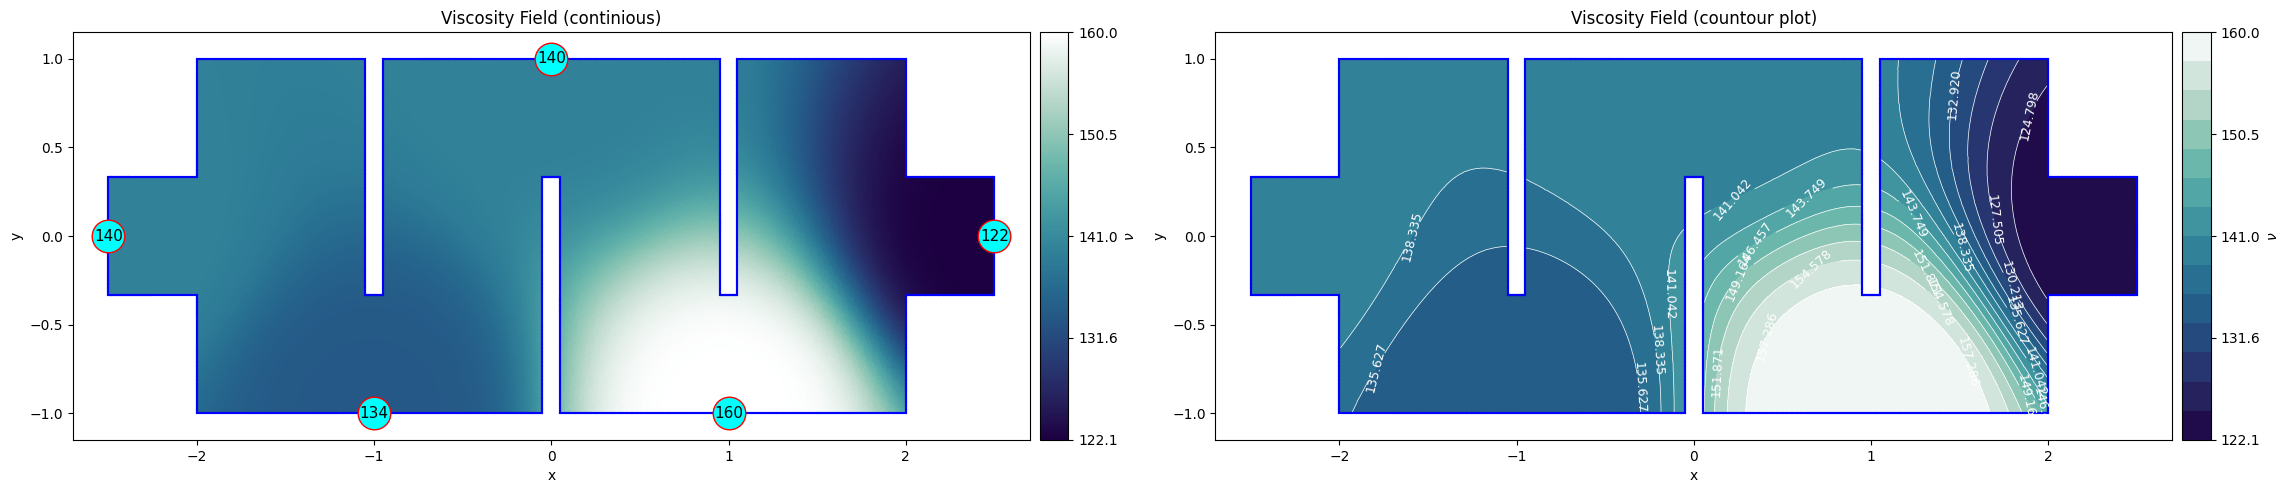

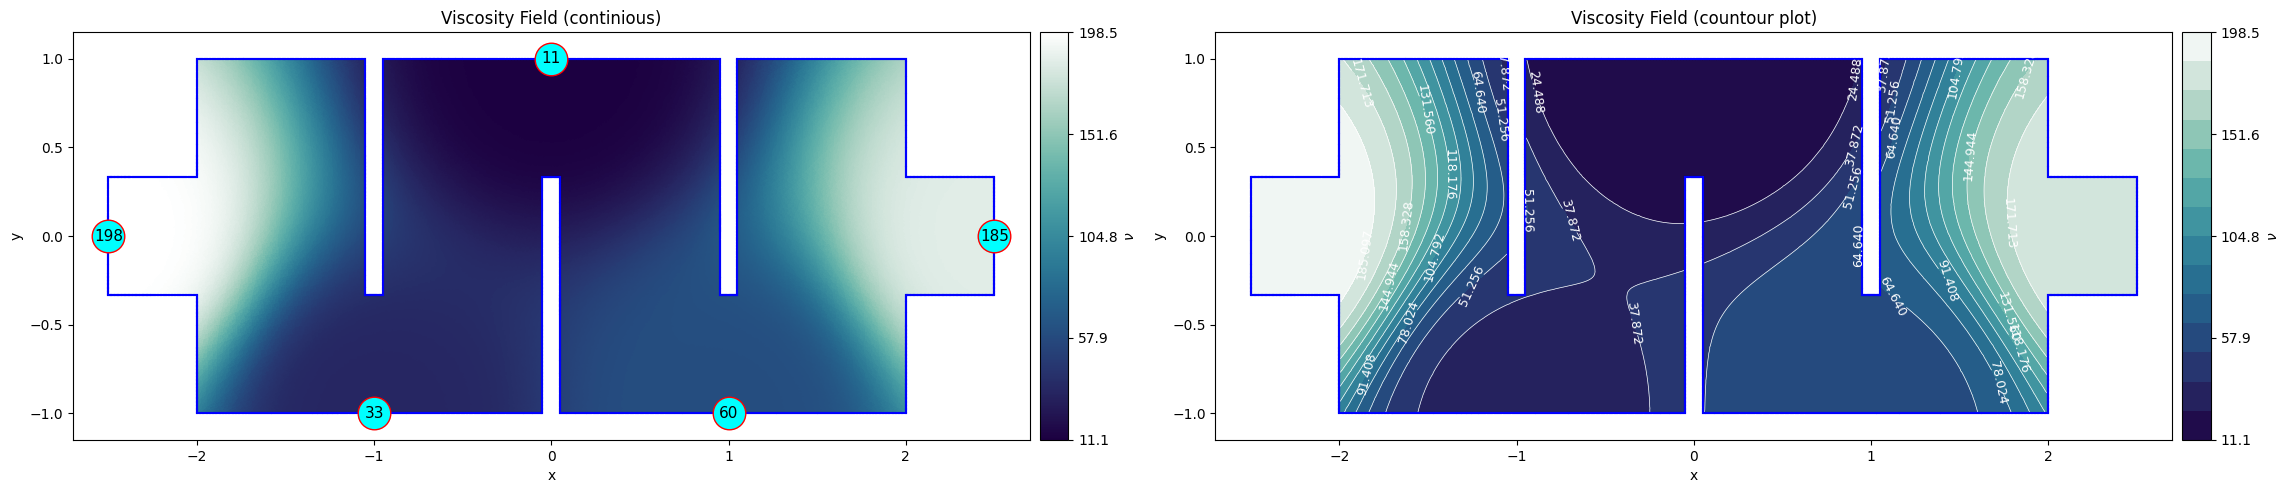

In [6]:
for snapshot_idx in [3, 7, 9]:
    v_t_snapshot    = v_t_snapshots[snapshot_idx]
    params_snapshot = parameters[snapshot_idx]

    nu_KNOTS = {
        'pts': knots,
        'vals': params_snapshot
    }

    plot_viscosity(p_fine, t_fine, e_fine, v_t_snapshot, nu_KNOTS,
                n_levels=15,
                figsize=(23, 10),
                savetype='png')

---

### Solution Snapshots

In [7]:
num_snapshots, Nv = ux_snapshots.shape
_, Np = p_snapshots.shape

U_mag = np.sqrt(ux_snapshots**2 + uy_snapshots**2)

print("\n" + "=" * 50)
print(" GLOBAL FIELD STATISTICS")
print("=" * 50)
print(f" Total Snapshots:     {num_snapshots}")
print("-" * 50)
print(f" Velocity Mag Min:    {np.min(U_mag):.6f}")
print(f" Velocity Mag Max:    {np.max(U_mag):.6f}")
print(f" Velocity Mag Mean:   {np.mean(U_mag):.6f}")
print("-" * 50)
print(f" Pressure Min:        {np.min(p_snapshots):.2f}")
print(f" Pressure Max:        {np.max(p_snapshots):.2f}")
print(f" Pressure Mean:       {np.mean(p_snapshots):.2f}")
print("=" * 50)


 GLOBAL FIELD STATISTICS
 Total Snapshots:     100
--------------------------------------------------
 Velocity Mag Min:    0.000000
 Velocity Mag Max:    0.335929
 Velocity Mag Mean:   0.125164
--------------------------------------------------
 Pressure Min:        -630.68
 Pressure Max:        4671.04
 Pressure Mean:       1566.04


Displaying Pre-computed Snapshot: 61
Knot Viscosity Values: [ 79.78  49.04 106.09 136.72 109.99]


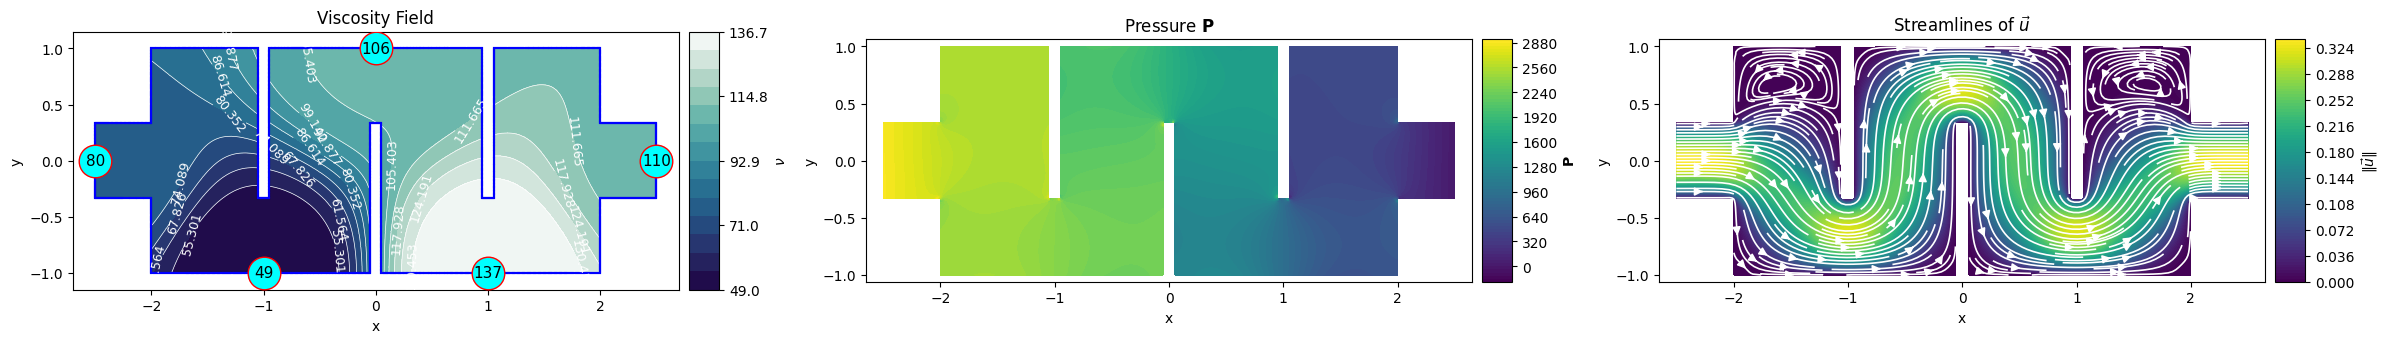

Displaying Pre-computed Snapshot: 38
Knot Viscosity Values: [113.15 105.77 120.7  175.89  64.  ]


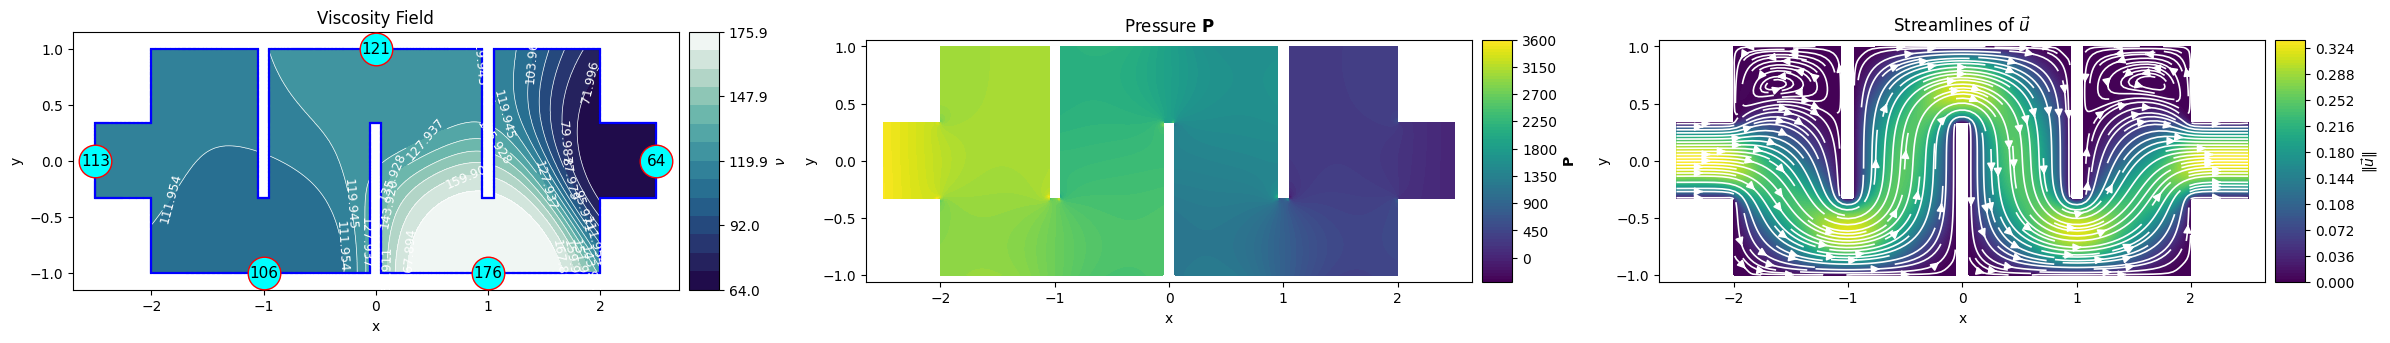

Displaying Pre-computed Snapshot: 45
Knot Viscosity Values: [189.52 116.27 110.48 113.79  68.18]


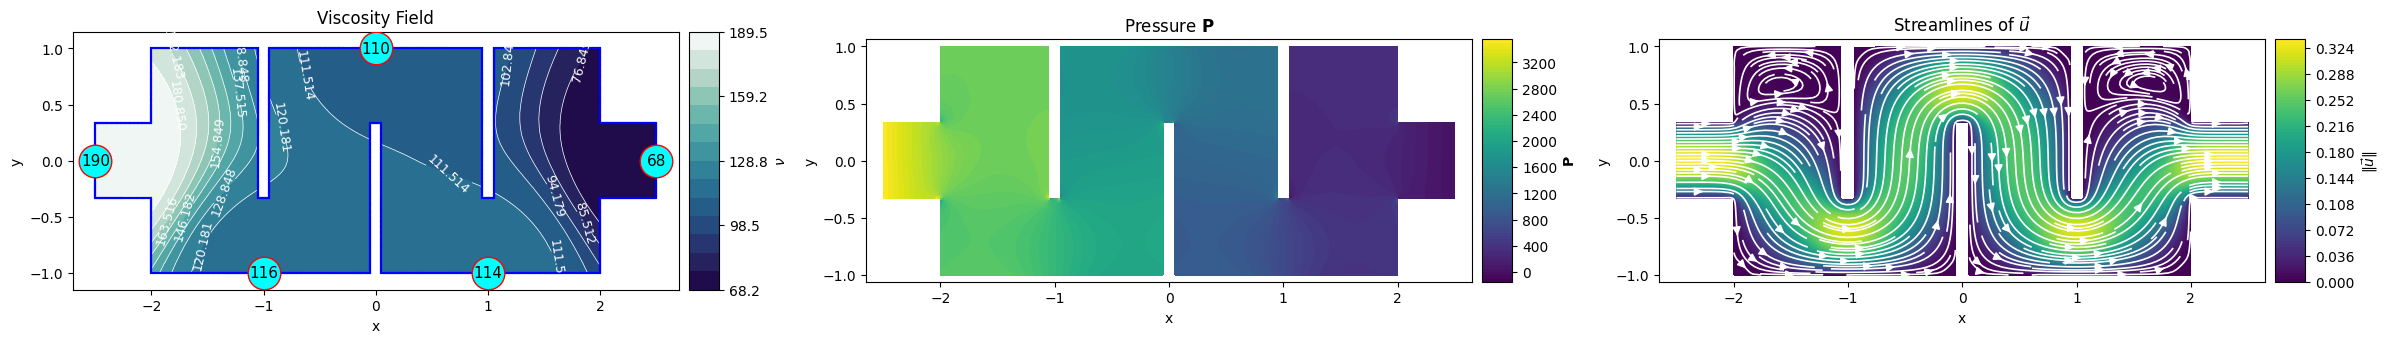

In [8]:
snapshots_to_plot =  np.random.choice(100, size=3, replace=False)

for i in snapshots_to_plot:
    v_t_snapshot = v_t_snapshots[i]
    params_snap  = parameters[i]
    
    ux_snapshot  = ux_snapshots[i]
    uy_snapshot  = uy_snapshots[i]
    p_snapshot   = p_snapshots[i]
    
    nu_KNOTS = {
        'pts': knots,
        'vals': params_snap
    }
    
    print(f"Displaying Pre-computed Snapshot: {i}")
    print(f"Knot Viscosity Values: {np.round(params_snap, 2)}")
    
    plot_combined_solution(
        p_fine=p_fine, t_fine=t_fine, ux=ux_snapshot, uy=uy_snapshot,
        p_coarse=p_coarse, t_coarse=t_coarse, p_sol=p_snapshot,
        p=p_fine, t=t_fine, e=e_fine, nu_T=v_t_snapshot, nu_KNOTS=nu_KNOTS,
        figsize=(24, 7), 
        savetype='png'
    )

---
# REDUCED ORDER MODEL
---

$$S_u = [\mathbf{u}_1, \mathbf{u}_2, \dots, \mathbf{u}_N]$$
$$S_p = [\mathbf{p}_1, \mathbf{p}_2, \dots, \mathbf{p}_N]$$

In [9]:
S_velocity = np.hstack([ux_snapshots, 
                        uy_snapshots])
S_pressure = p_snapshots

Computing the $X_u$, $B_h^T$:

In [10]:
_, _, _, Xu, B_hT = compute_U_P_solution_exchanger_device(p_fine, t_fine, e_fine,
                                         p_coarse, t_coarse, alpha=3, kinematic_viscosity=1, 
                                         return_matrices=True)

In [11]:
solve_Xu = spla.factorized(Xu.tocsc())

rhs_tensor = B_hT.dot(S_pressure.T)
S_t = solve_Xu(rhs_tensor)

In [12]:
print(f"Xu shape:                {Xu.shape}")
print(f"B_hT shape:              {B_hT.shape}")
print(f"S_t shape:               {S_t.shape}")

Xu shape:                (182546, 182546)
B_hT shape:              (182546, 23077)
S_t shape:               (182546, 100)


Building the lift; Homogenizing velocity snapshots:
$$
\displaystyle
\mathbf{u}_{\text{f}} = \mathbf{u}_{\text{l}} + \mathbf{u}_{\text{h}} = \mathbf{u}_{\text{l}} + \sum_i u_i \boldsymbol{\phi}_i
$$

In [13]:
eps  = 1e-10
Nv = p_fine.shape[0]
Np = p_coarse.shape[0]

xmin = p_fine[:, 0].min()
inlet_idx = np.where(np.abs(p_fine[:, 0] - xmin) < eps)[0]
corner_idx  = [inlet_idx[np.argmax(p_fine[inlet_idx, 1])], 
               inlet_idx[np.argmin(p_fine[inlet_idx, 1])]]

lf = np.zeros(2 * Nv)
y_inlet = p_fine[inlet_idx, 1]
y_top, y_bottom = p_fine[corner_idx[0], 1], p_fine[corner_idx[1], 1]
lf[:Nv][inlet_idx] = parabolic_inlet_profile(y_inlet, y_top, y_bottom, alpha=3)

S_velocity_homog = S_velocity - lf[None, :]   # subtracting lift from every snapshot row -> homogeneous u0

Train/Test split:

In [14]:
test_idx  = 0
train_idx = np.arange(1, S_velocity.shape[0])

Basis calcualation via SVD:

In [15]:
def pod_basis(S, energy:float=0.9999, name:str="",
              plot:bool=False,
              manual_selection:bool=False, k:int=5):
    
    _U, s, _ = np.linalg.svd(S.T, full_matrices=False)

    if manual_selection:
        return _U[:, :k]
    
    normalized_eigenvalues = np.cumsum(s**2) / np.sum(s**2)    
    _N = int(np.searchsorted(normalized_eigenvalues, energy) + 1)
    enery_true = normalized_eigenvalues[_N-1]
    print(f"[{name}] kept {_N}/{len(s)} modes, energy = {enery_true:.6f}")

    if plot:
        plt.figure(figsize=(15, 5))

        plt.plot(normalized_eigenvalues, 
                linestyle='-',
                marker='o', 
                markersize=3.5,
                color="#373eac",
                linewidth=1.5,
                label="Cumulative Energy")
        
        plt.axhline(y=energy,
                    color="green",
                    linestyle="--",
                    linewidth=1.2,
                    label=f"Target energy ({energy * 100}%)")
        
        plt.axhline(y=enery_true,
                    color="crimson",
                    linestyle="--",
                    linewidth=1.2,
                    label=f"Selected energy ({enery_true * 100:.4f}%)")

        plt.scatter(_N-1,
                    normalized_eigenvalues[_N - 1],
                    color="#39003A",
                    marker="x",
                    s=130,
                    linewidth=2.5,
                    zorder=5,
                    label=f"Selected {_N} modes")
        
        plt.title(f"POD Energy Spectrum — {name.capitalize()}", fontsize=12, weight="bold", pad=12)
        plt.xlabel("Snapshot / Mode Index ($i$)", fontsize=11)
        plt.ylabel("Cumulative Energy Ratio / $\\lambda_i / \\sum_i \\lambda_i$", fontsize=11)

        plt.legend(frameon=True, facecolor="white", edgecolor="none", fontsize=10)
        plt.grid(True, which="both", ls="--", alpha=0.3)
        plt.savefig(f'Outputs/POD_Energy_Spectrum_{name}.png')
        plt.show()
    
    return _U[:, :_N]

[velocity (homogeneous)] kept 5/99 modes, energy = 0.999931


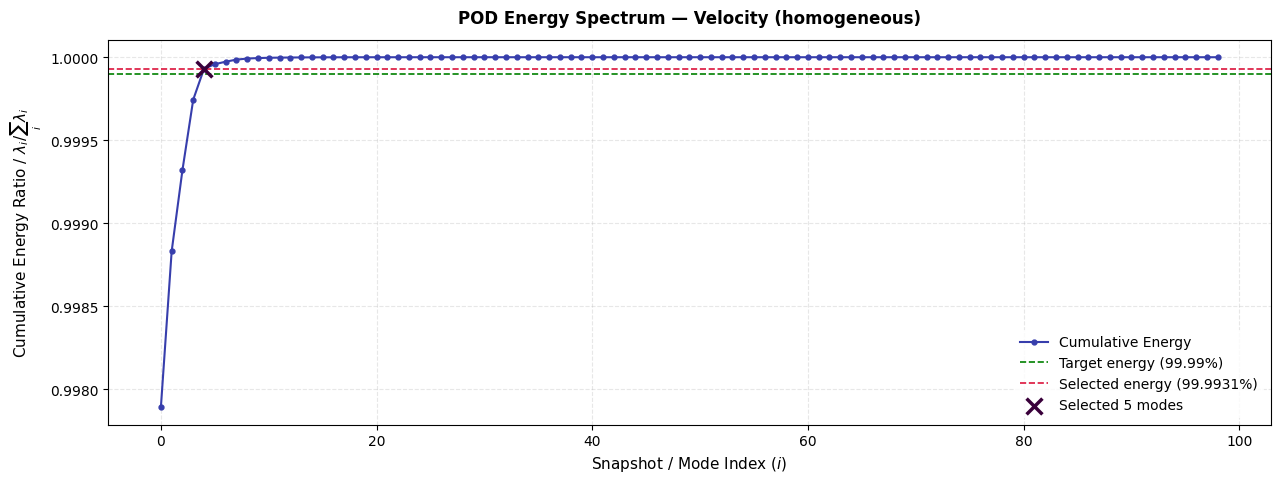

[supremizer] kept 6/99 modes, energy = 0.999939


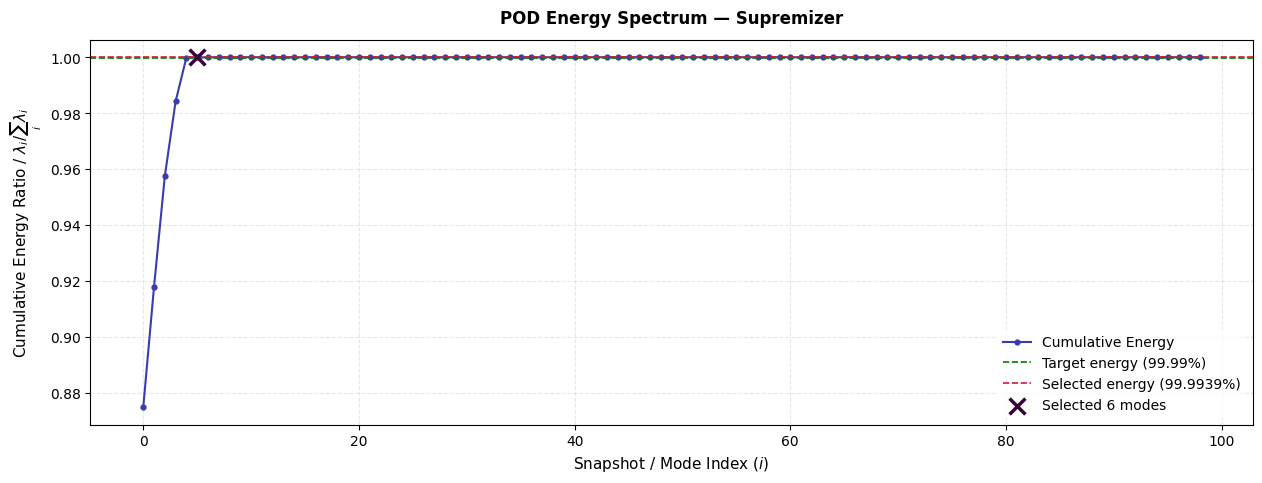

[pressure] kept 5/99 modes, energy = 0.999999


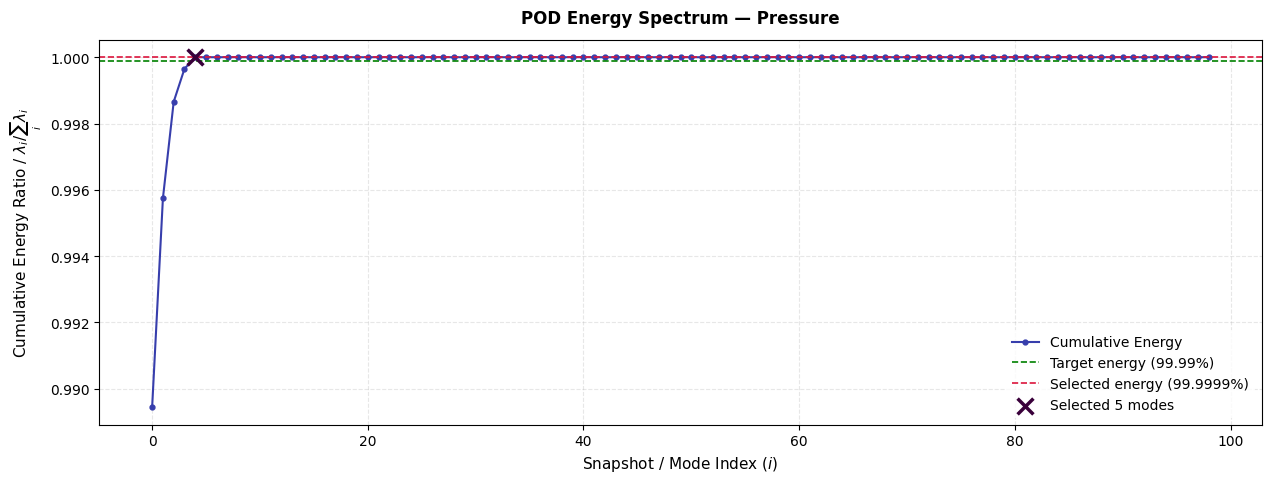

Vu shape: (182546, 11)   Vp shape: (23077, 5)


In [16]:
Vu_tilde = pod_basis(S_velocity_homog[train_idx], energy=0.9999, name="velocity (homogeneous)", plot=True)
Vs       = pod_basis(S_t.T[train_idx],            energy=0.9999, name="supremizer", plot=True)
Vp       = pod_basis(S_pressure[train_idx],       energy=0.9999, name="pressure", plot=True)

Vu = np.hstack([Vu_tilde, Vs])
print(f"Vu shape: {Vu.shape}   Vp shape: {Vp.shape}")

Constructing a reduced model:

In [17]:
def solve_ROM(p_fine, t_fine, Bh, nu_field, Vu, Vp, lifting_f):
    
    A_mu   = calculate_velocity_A(p_fine, t_fine, kinematic_viscosity=nu_field)
    Xu_mu = sp.block_diag([A_mu, A_mu]).tocsc()

    Lap_N = Vu.T @ (Xu_mu @ Vu)
    Div_N = Vp.T @ (Bh @ Vu)
    f_N = Vu.T @ (-(Xu_mu @ lifting_f))
    g_N = Vp.T @ (-(Bh    @ lifting_f))

    Nu_, Np_ = Lap_N.shape[0], Div_N.shape[0]

    K_N = np.block([[Lap_N, Div_N.T], 
                    [Div_N, np.zeros((Np_, Np_))]])
                    
    sol_N = np.linalg.solve(K_N, np.concatenate([f_N, 
                                                 g_N]))
    u_N, p_N = sol_N[:Nu_], sol_N[Nu_:]
    u_red = Vu @ u_N + lifting_f # (Adding the lift back)
    
    return u_red[:Nv], u_red[Nv:], Vp @ p_N

We calculate $\mathbf{B}$ once:

In [18]:
Bx, By = calculate_pressure_B(p_fine, t_fine, p_coarse, t_coarse)
Bh  = sp.hstack([Bx, By]).tocsc()

In [19]:
ux_rom, uy_rom, p_rom = solve_ROM(p_fine, t_fine, Bh, v_t_snapshots[test_idx], Vu, Vp, lf)
ux_true, uy_true, p_true = ux_snapshots[test_idx], uy_snapshots[test_idx], p_snapshots[test_idx]

Plots & Checks:

Relative L2 error |U|: 3.721e-03
Relative L2 error  p : 4.280e-04


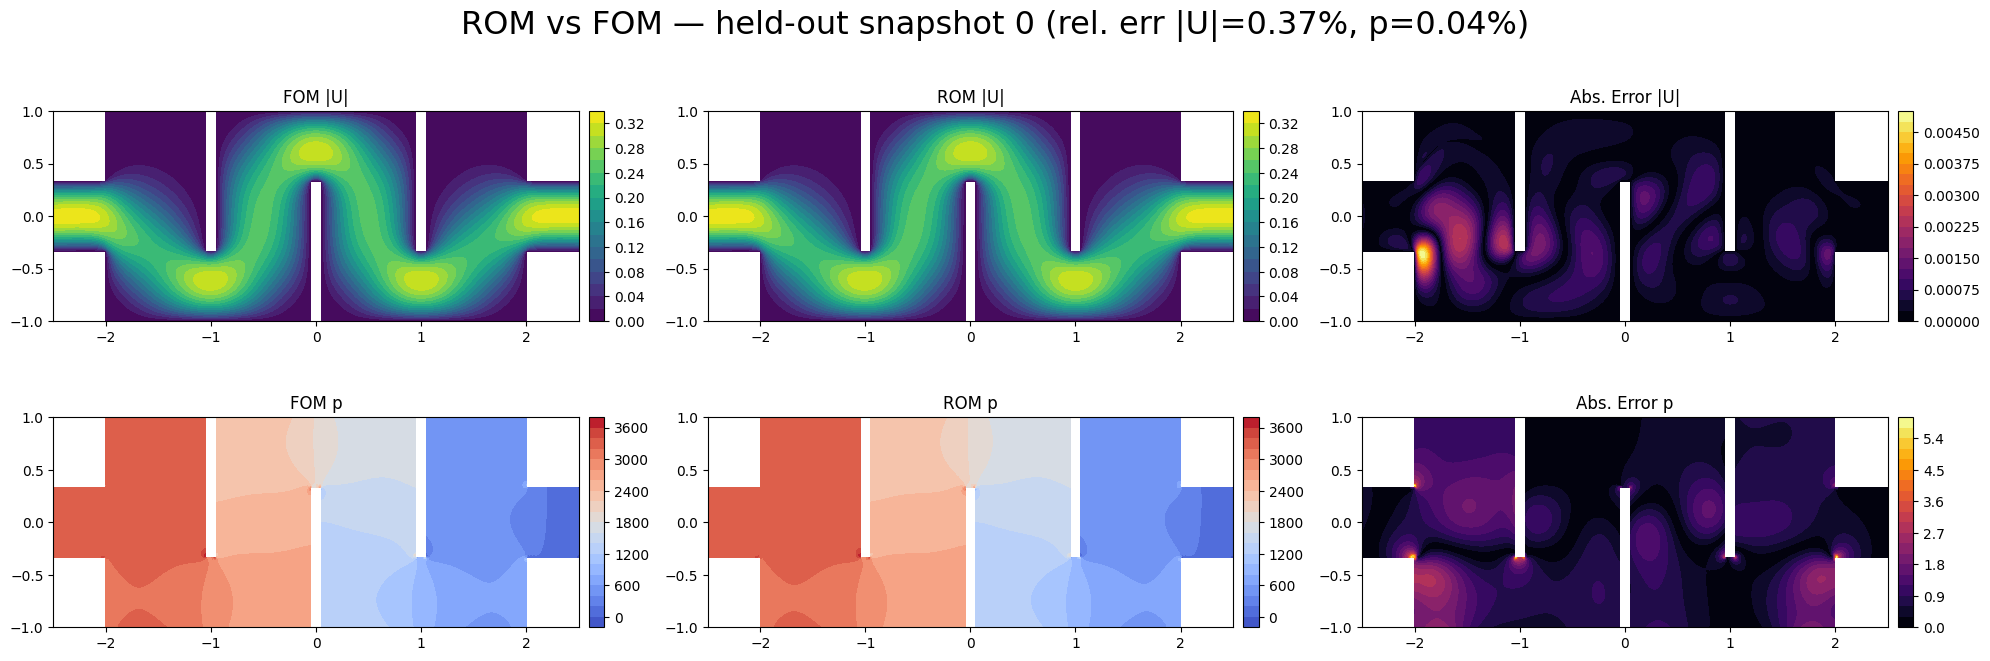

In [20]:

Umag_true = np.sqrt(ux_true**2 + uy_true**2)
Umag_rom  = np.sqrt(ux_rom**2  + uy_rom**2)
abs_err_u = np.abs(Umag_rom - Umag_true)
abs_err_p = np.abs(p_rom - p_true)

rel_u = np.linalg.norm(Umag_rom - Umag_true) / np.linalg.norm(Umag_true)
rel_p = np.linalg.norm(p_rom - p_true) / np.linalg.norm(p_true)
print(f"Relative L2 error |U|: {rel_u:.3e}")
print(f"Relative L2 error  p : {rel_p:.3e}")



tri_fine   = plt.matplotlib.tri.Triangulation(p_fine[:, 0],   p_fine[:, 1],   t_fine[:, :3])
tri_coarse = plt.matplotlib.tri.Triangulation(p_coarse[:, 0], p_coarse[:, 1], t_coarse[:, :3])

fig, axes = plt.subplots(2, 3, figsize=(20, 7))

for ax, field, title, cmap in zip(
    axes[0],
    [Umag_true, Umag_rom, abs_err_u],
    ["FOM |U|", "ROM |U|", "Abs. Error |U|"],
    ['viridis', 'viridis', 'inferno']
):
    cf = ax.tricontourf(tri_fine, field, levels=20, cmap=cmap)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3%", pad=0.1)
    fig.colorbar(cf, cax=cax)
    ax.set_title(title)
    ax.set_aspect('equal')

for ax, field, title, cmap in zip(
    axes[1],
    [p_true, p_rom, abs_err_p],
    ["FOM p", "ROM p", "Abs. Error p"],
    ['coolwarm', 'coolwarm', 'inferno']
):
    cf = ax.tricontourf(tri_coarse, field, levels=20, cmap=cmap)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3%", pad=0.1)
    fig.colorbar(cf, cax=cax)
    ax.set_title(title)
    ax.set_aspect('equal')

plt.suptitle(
    f"ROM vs FOM — held-out snapshot {test_idx} "
    f"(rel. err |U|={rel_u:.2%}, p={rel_p:.2%})", fontsize = 23
)
plt.tight_layout()
plt.show()

---

Tests:

In [21]:
# ---- Diagnostic: is snapshot 0 an extreme outlier? ----
nu_min_per_snap = v_t_snapshots.min(axis=1)
print("nu_min across all snapshots — min/mean/max:",
      nu_min_per_snap.min(), nu_min_per_snap.mean(), nu_min_per_snap.max())
print(f"Snapshot 0's min viscosity: {nu_min_per_snap[0]:.6f}  "
      f"(rank {np.sum(nu_min_per_snap <= nu_min_per_snap[0])} of {len(nu_min_per_snap)}, lower = more extreme)")

p_range_per_snap = p_snapshots.max(axis=1) - p_snapshots.min(axis=1)
print(f"Snapshot 0's pressure range: {p_range_per_snap[0]:.1f}  "
      f"vs. dataset median: {np.median(p_range_per_snap):.1f}")

# ---- Proper leave-one-out sweep across several snapshots (not just idx 0) ----
test_pool = np.random.choice(np.arange(100), size=15, replace=False)
results = []

Bx, By = calculate_pressure_B(p_fine, t_fine, p_coarse, t_coarse)
Bh  = sp.hstack([Bx, By]).tocsc()

for t_idx in test_pool:
    train_i = np.setdiff1d(np.arange(100), [t_idx])

    Vu_t = pod_basis(S_velocity_homog[train_i], energy=0.9999, name=f"vel[{t_idx}]")
    Vs_t = pod_basis(S_t.T[train_i],            energy=0.9999, name=f"sup[{t_idx}]")
    Vp_t = pod_basis(S_pressure[train_i],       energy=0.9999, name=f"pres[{t_idx}]")
    Vu_l, Vp_l = np.hstack([Vu_t, Vs_t]), Vp_t
    B_N_l = Vp_l.T @ (Bh @ Vu_l)

    A_mu  = calculate_velocity_A(p_fine, t_fine, v_t_snapshots[t_idx])
    Xu_mu = sp.block_diag([A_mu, A_mu]).tocsc()
    D_N = Vu_l.T @ (Xu_mu @ Vu_l)
    F_N = Vu_l.T @ (-(Xu_mu @ lf))
    G_N = Vp_l.T @ (-(Bh   @ lf))
    Nu_, Np_ = D_N.shape[0], B_N_l.shape[0]
    K_N = np.block([[D_N, B_N_l.T], [B_N_l, np.zeros((Np_, Np_))]])
    sol_N = np.linalg.solve(K_N, np.concatenate([F_N, G_N]))
    u_red = Vu_l @ sol_N[:Nu_] + lf
    p_red = Vp_l @ sol_N[Nu_:]

    Umag_t = np.sqrt(ux_snapshots[t_idx]**2 + uy_snapshots[t_idx]**2)
    Umag_r = np.sqrt(u_red[:Nv]**2 + u_red[Nv:]**2)
    ru = np.linalg.norm(Umag_r - Umag_t) / np.linalg.norm(Umag_t)
    rp = np.linalg.norm(p_red - p_snapshots[t_idx]) / np.linalg.norm(p_snapshots[t_idx])
    results.append((t_idx, nu_min_per_snap[t_idx], ru, rp))
    print(f"idx {t_idx:3d}  nu_min={nu_min_per_snap[t_idx]:.4f}  rel_err_U={ru:.2%}  rel_err_p={rp:.2%}\n")

results = np.array(results)
print(f"\nMedian rel err |U|: {np.median(results[:,2]):.2%}   Median rel err p: {np.median(results[:,3]):.2%}")

nu_min across all snapshots — min/mean/max: 10.39372712019004 40.43899302499343 122.09086355971161
Snapshot 0's min viscosity: 23.528760  (rank 32 of 100, lower = more extreme)
Snapshot 0's pressure range: 3962.8  vs. dataset median: 3503.0
[vel[40]] kept 5/99 modes, energy = 0.999931
[sup[40]] kept 6/99 modes, energy = 0.999939
[pres[40]] kept 5/99 modes, energy = 0.999999
idx  40  nu_min=39.8413  rel_err_U=0.33%  rel_err_p=0.05%

[vel[39]] kept 5/99 modes, energy = 0.999931
[sup[39]] kept 6/99 modes, energy = 0.999939
[pres[39]] kept 5/99 modes, energy = 0.999999
idx  39  nu_min=27.5366  rel_err_U=0.34%  rel_err_p=0.04%

[vel[38]] kept 5/99 modes, energy = 0.999931
[sup[38]] kept 6/99 modes, energy = 0.999940
[pres[38]] kept 5/99 modes, energy = 0.999999
idx  38  nu_min=64.0044  rel_err_U=0.40%  rel_err_p=0.05%

[vel[5]] kept 5/99 modes, energy = 0.999934
[sup[5]] kept 6/99 modes, energy = 0.999940
[pres[5]] kept 5/99 modes, energy = 0.999999
idx   5  nu_min=17.3108  rel_err_U=1.91% 

In [22]:
Vu_tilde = pod_basis(S_velocity_homog[train_idx], energy=0.9999, name="velocity (homogeneous)", plot=True, manual_selection=True, k=99)
Vs       = pod_basis(S_t.T[train_idx],            energy=0.9999, name="supremizer", plot=True, manual_selection=True, k=99)
Vp       = pod_basis(S_pressure[train_idx],       energy=0.9999, name="pressure", plot=True, manual_selection=True, k=99)

Vu = np.hstack([Vu_tilde, Vs])
print(f"Vu shape: {Vu.shape}   Vp shape: {Vp.shape}")

Vu shape: (182546, 198)   Vp shape: (23077, 99)


In [23]:
ux_rom, uy_rom, p_rom = solve_ROM(p_fine, t_fine, Bh, v_t_snapshots[test_idx], Vu, Vp, lf)
ux_true, uy_true, p_true = ux_snapshots[test_idx], uy_snapshots[test_idx], p_snapshots[test_idx]

Relative L2 error |U|: 4.819e-07
Relative L2 error  p : 7.613e-09


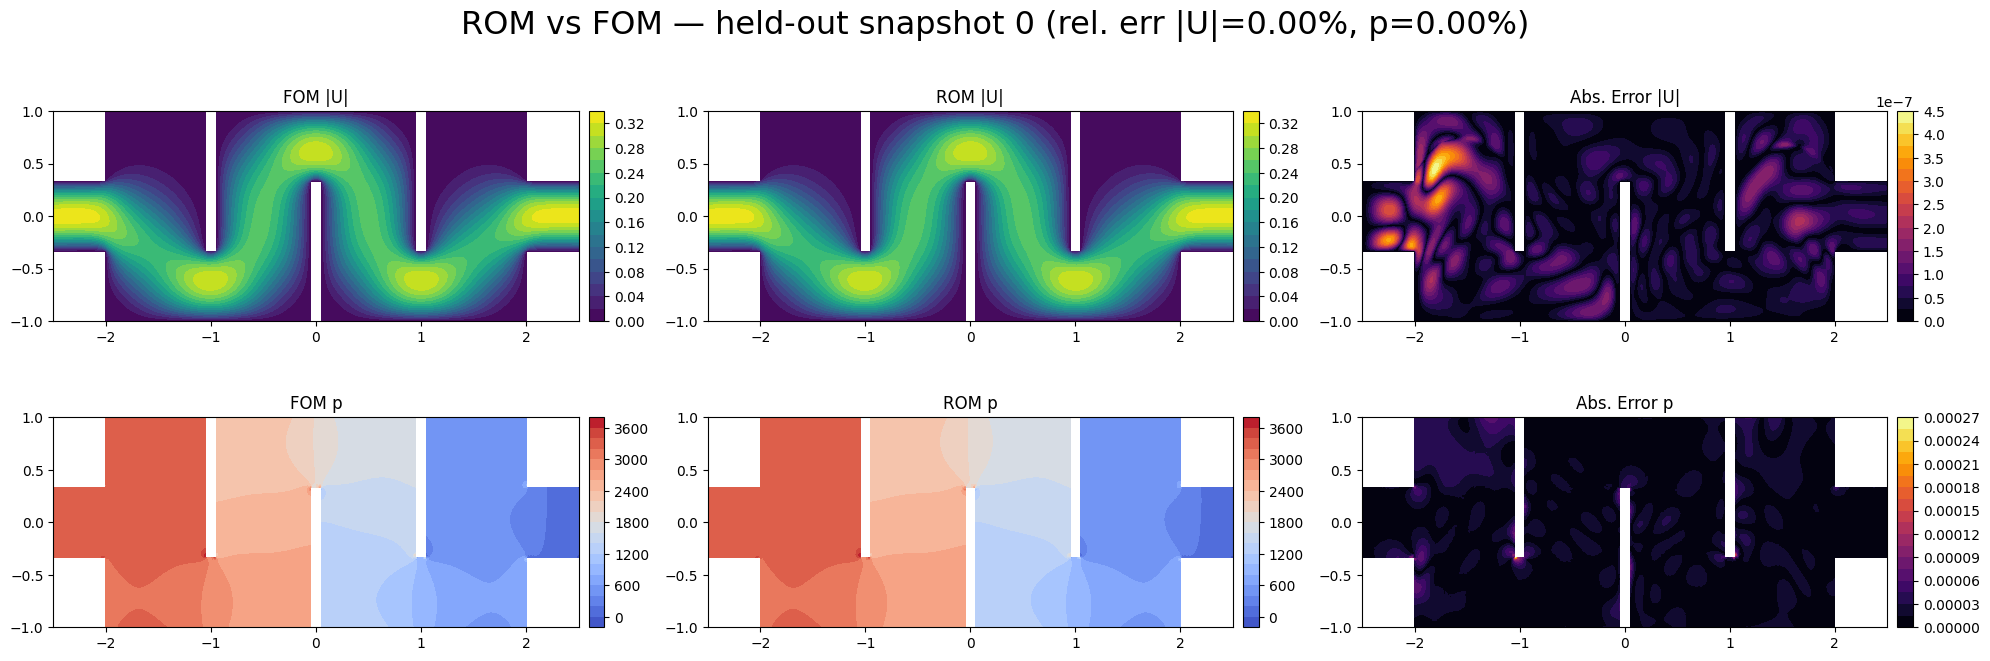

In [24]:

Umag_true = np.sqrt(ux_true**2 + uy_true**2)
Umag_rom  = np.sqrt(ux_rom**2  + uy_rom**2)
abs_err_u = np.abs(Umag_rom - Umag_true)
abs_err_p = np.abs(p_rom - p_true)

rel_u = np.linalg.norm(Umag_rom - Umag_true) / np.linalg.norm(Umag_true)
rel_p = np.linalg.norm(p_rom - p_true) / np.linalg.norm(p_true)
print(f"Relative L2 error |U|: {rel_u:.3e}")
print(f"Relative L2 error  p : {rel_p:.3e}")

tri_fine   = plt.matplotlib.tri.Triangulation(p_fine[:, 0],   p_fine[:, 1],   t_fine[:, :3])
tri_coarse = plt.matplotlib.tri.Triangulation(p_coarse[:, 0], p_coarse[:, 1], t_coarse[:, :3])

fig, axes = plt.subplots(2, 3, figsize=(20, 7))

for ax, field, title, cmap in zip(
    axes[0],
    [Umag_true, Umag_rom, abs_err_u],
    ["FOM |U|", "ROM |U|", "Abs. Error |U|"],
    ['viridis', 'viridis', 'inferno']
):
    cf = ax.tricontourf(tri_fine, field, levels=20, cmap=cmap)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3%", pad=0.1)
    fig.colorbar(cf, cax=cax)
    ax.set_title(title)
    ax.set_aspect('equal')

for ax, field, title, cmap in zip(
    axes[1],
    [p_true, p_rom, abs_err_p],
    ["FOM p", "ROM p", "Abs. Error p"],
    ['coolwarm', 'coolwarm', 'inferno']
):
    cf = ax.tricontourf(tri_coarse, field, levels=20, cmap=cmap)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3%", pad=0.1)
    fig.colorbar(cf, cax=cax)
    ax.set_title(title)
    ax.set_aspect('equal')

plt.suptitle(
    f"ROM vs FOM — held-out snapshot {test_idx} "
    f"(rel. err |U|={rel_u:.2%}, p={rel_p:.2%})", fontsize = 23
)
plt.tight_layout()
plt.show()

---